Confusion matrix, without normalization
[[418 109]
 [168 351]]
Normalized confusion matrix
[[0.79316888 0.20683112]
 [0.32369942 0.67630058]]


/tmp/ipykernel_52637/294453199.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


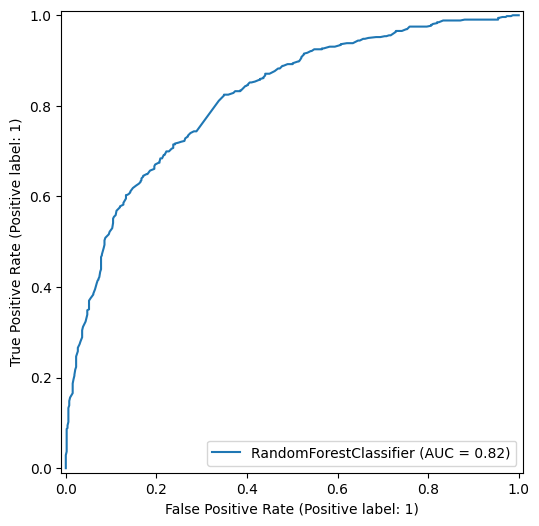

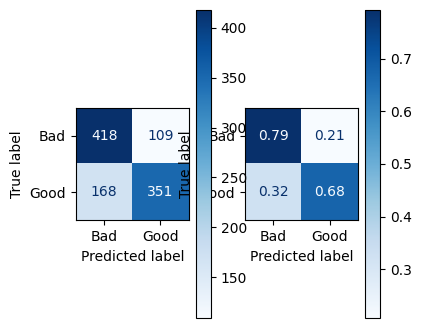

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import json
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("../data/heloc/train.csv")
df_test = pd.read_csv("../data/heloc/test.csv")

with open("../data/heloc/info.json","r") as f:
    INFO = json.load(f)


Scaler = {}
New_data = {}
for i,col in enumerate(df.columns):

    if i in INFO['num_col_idx']:
        se = StandardScaler()
        se.fit(df[col].values.reshape(-1,1))
        Scaler[col] = se
        New_data[col] = se.transform(df[col].values.reshape(-1,1)).flatten()
    
    elif i in INFO['cat_col_idx'] or INFO['target_col_idx']:
        le = LabelEncoder()
        le.fit(df[col].values.flatten())
        Scaler[col] = le
        New_data[col] = le.transform(df[col].values.flatten()).flatten()
    

df_trans = pd.DataFrame(New_data)


X_train = df_trans.iloc[:,1:]
y_train = df_trans.iloc[:,0]


Scaler_test = {}
New_data = {}
for i,col in enumerate(df_test.columns):

    if i in INFO['num_col_idx']:
        se = StandardScaler()
        se.fit(df_test[col].values.reshape(-1,1))
        Scaler_test[col] = se
        New_data[col] = se.transform(df_test[col].values.reshape(-1,1)).flatten()
    
    elif i in INFO['cat_col_idx'] or INFO['target_col_idx']:
        #le = LabelEncoder()
        #le.fit(df_test[col].values.flatten())
        Scaler_test[col] = Scaler[col]
        New_data[col] = Scaler[col].transform(df_test[col].values.flatten()).flatten()
    

df_test_trans = pd.DataFrame(New_data)


X_test = df_test_trans.iloc[:,1:]
y_test = df_test_trans.iloc[:,0]
forest = RandomForestClassifier(random_state=0,n_estimators=200,)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve





def confusion_matrix(y_pred,y_test):

    negatives = ((y_test==0)*1).sum()
    positives = ((y_test==1)*1).sum()
    tnr = (((y_pred-y_test) == 1)*(y_test==0)*1).sum()/negatives
    tpr = (((y_pred-y_test) == 1)*(y_test==1)*1).sum()/positives
    fpr = (((y_pred-y_test) ==1)*1).sum()/negatives#(y_pred-y_test).value_counts()[-1]/negatives
    fnr = (((y_pred-y_test) ==-1)*1).sum()/positives#(y_pred-y_test).value_counts()[1]/positives
    return tnr,tpr,fpr,fnr

confusion_matrix(forest.predict(X_test),y_test)



fig, ax = plt.subplots(1,1,figsize=(12,6))


svc_disp = RocCurveDisplay.from_estimator(forest, X_test, y_test,ax=ax)

y_score = forest.predict_proba(X_test)
prec, recall, _ = precision_recall_curve(y_test, y_score[:,1], pos_label=forest.classes_[1])
#pr_display = PrecisionRecallDisplay(precision=prec, recall=recall).plot(ax=ax[1])

class_names = ['Bad','Good']#y_train.unique()

fig1,ax2 = plt.subplots(1,2,figsize=(4,4))
i=0
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        forest,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,ax=ax2[i]
    )
    #disp.ax[i].set_title(title)
    i+=1
    print(title)
    print(disp.confusion_matrix)

fig1.show()


--- Imbalance Creation Summary ---
Target Ratio (0:1): 5.0:1
Majority (0) Count: 4481
Required Minority (1) Count: 896
Current Minority (1) Count: 4932
Number of indices to drop: 4036
--- Result ---
New Minority (1) Count: 4481
Actual New Ratio (0:1): 1.00:1


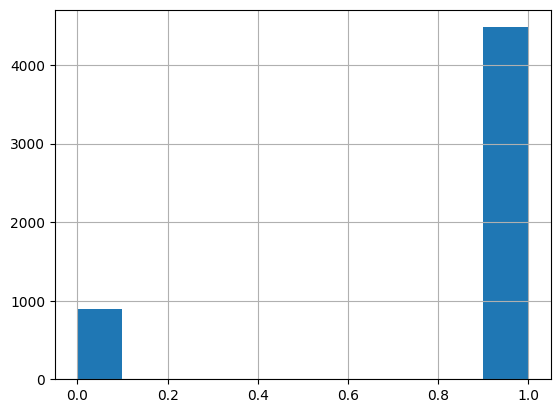

In [2]:
# Assuming your DataFrame is named 'df' and the target column is 'target'

# --- 1. Define the Target Ratio ---
# For example, a 10:1 ratio means there will be 10 majority samples for every 1 minority sample.
TARGET_RATIO = 5.0 # Majority:Minority (e.g., 10 for 10:1)

# --- 2. Get Current Class Counts ---
majority_count = len(df_trans[df_trans['RiskPerformance'] == 1])
minority_indices = df_trans[df_trans['RiskPerformance'] == 0].index
current_minority_count = len(minority_indices)

# --- 3. Calculate Required Minority Count ---
# Target Ratio = Majority Count / Required Minority Count
# Required Minority Count = Majority Count / Target Ratio
required_minority_count = int(majority_count / TARGET_RATIO)

# --- 4. Calculate How Many to Drop ---
num_to_drop = current_minority_count - required_minority_count

if num_to_drop <= 0:
    print(f"Cannot achieve a {TARGET_RATIO}:1 ratio by dropping. Need to drop {-num_to_drop} MORE majority samples.")
else:
    # --- 5. Randomly Select and Drop Indices ---
    np.random.seed(42) # Optional: for reproducibility
    indices_to_drop = np.random.choice(
        minority_indices,
        size=num_to_drop,
        replace=False
    )

    df_imbalanced = df_trans.drop(indices_to_drop)
    
    # --- Verification ---
    new_minority_count = len(df_imbalanced[df_imbalanced['RiskPerformance'] == 1])
    actual_ratio = majority_count / new_minority_count
    
    print("--- Imbalance Creation Summary ---")
    print(f"Target Ratio (0:1): {TARGET_RATIO}:1")
    print(f"Majority (0) Count: {majority_count}")
    print(f"Required Minority (1) Count: {required_minority_count}")
    print(f"Current Minority (1) Count: {current_minority_count}")
    print(f"Number of indices to drop: {num_to_drop}")
    print("--- Result ---")
    print(f"New Minority (1) Count: {new_minority_count}")
    print(f"Actual New Ratio (0:1): {actual_ratio:.2f}:1")

df_imbalanced['RiskPerformance'].hist()



X_train_imb = df_imbalanced.iloc[:,1:]
y_train_imb = df_imbalanced.iloc[:,0]




In [3]:
from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

RESULTS = {}
for method in ['tabsyn','tabdiff','tabddpm','tabscm','dcm','great','Smote','ADASYN','goggle','ctgan','causalTGAN']:
    RESULTS[method]= {'FNR':[],'FPR':[]}
    for i in range(1,6):
        if not method in ['Smote','ADASYN']:
            if method == 'dcm': 
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/heloc{i-1}.csv')
            elif method == 'tabscm': 
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/sample_test{i}.csv')
            elif method == 'goggle':
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/goggle{i}.csv')
            else:
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/sample{i}.csv')
                
                    

            tabsyn_df = tabsyn_df[tabsyn_df['RiskPerformance'] == 'Bad'].reset_index().drop(columns=['index'])


            New_data = {}
            for i,col in enumerate(tabsyn_df.columns):

                if i in INFO['num_col_idx']:
                    New_data[col] = Scaler[col].transform(tabsyn_df[col].values.reshape(-1,1)).flatten()
                
                elif i in INFO['cat_col_idx'] or INFO['target_col_idx']:
                    New_data[col] = Scaler[col].transform(tabsyn_df[col].values.flatten()).flatten()
                

            df_trans_tabsyn = pd.DataFrame(New_data)


            X_train_tabsyn = df_trans_tabsyn.iloc[:,1:]
            y_train_tabsyn = df_trans_tabsyn.iloc[:,0]

            N= (y_train_imb == 1).sum()-(y_train_imb==0).sum()
            # import numpy as np
            try:
                INDICES = np.random.choice(np.arange(1,X_train_tabsyn.shape[0]),N,replace=False)
            except:
                INDICES = np.arange(len(X_train_tabsyn))



            X_train_up = pd.concat([X_train_imb,X_train_tabsyn.iloc[INDICES,:]])
            y_train_up = pd.concat([y_train_imb,y_train_tabsyn.iloc[INDICES]])
        else:
            if method == 'ADASYN':
                ada_syn = ADASYN(random_state=i)

                X_train_up, y_train_up = ada_syn.fit_resample(X_train_imb, y_train_imb)

            elif method == 'Smote':
                smote = SMOTE(random_state=i)

                X_train_up, y_train_up = smote.fit_resample(X_train_imb, y_train_imb)




        forest = RandomForestClassifier(random_state=0,n_estimators=100,)#LogisticRegression()#GradientBoostingClassifier(random_state=0)#RandomForestClassifier(random_state=0,n_estimators=50,)KNeighborsClassifier(n_neighbors=5)
        forest.fit(X_train_up, y_train_up)
        
        y_pred = forest.predict(X_test)


        cm = confusion_matrix(y_pred,y_test)
    
        print('FPR',cm[2])
        RESULTS[method]['FPR'].append(cm[2])
        print('FNR',cm[3])
        RESULTS[method]['FNR'].append(cm[3])


FPR 0.23529411764705882
FNR 0.3179190751445087
FPR 0.21821631878557876
FNR 0.3352601156069364
FPR 0.2239089184060721
FNR 0.3179190751445087
FPR 0.2409867172675522
FNR 0.3179190751445087
FPR 0.2049335863377609
FNR 0.3179190751445087
FPR 0.20683111954459202
FNR 0.3236994219653179
FPR 0.23529411764705882
FNR 0.3198458574181118
FPR 0.222011385199241
FNR 0.3198458574181118
FPR 0.2333965844402277
FNR 0.3198458574181118
FPR 0.23529411764705882
FNR 0.3159922928709056
FPR 0.2504743833017078
FNR 0.2774566473988439
FPR 0.2409867172675522
FNR 0.29672447013487474
FPR 0.23908918406072105
FNR 0.2928709055876686
FPR 0.29601518026565465
FNR 0.21965317919075145
FPR 0.24667931688804554
FNR 0.3063583815028902
FPR 0.25426944971537
FNR 0.29865125240847784
FPR 0.2656546489563567
FNR 0.2813102119460501
FPR 0.2675521821631879
FNR 0.29865125240847784
FPR 0.269449715370019
FNR 0.28516377649325625
FPR 0.2523719165085389
FNR 0.3063583815028902
FPR 0.051233396584440226
FNR 0.9325626204238922
FPR 0.05123339658444022

In [4]:
fpr = 0.21
fnr = 0.32

In [5]:
fnr_data_5 = {}
fpr_data_5 = {}

for k,v in RESULTS.items():
    fnr_data_5[k] = np.array(v['FNR'])#-fnr
    fpr_data_5[k] = np.array(v['FPR'])#-fpr



fpr_df_5 = pd.DataFrame(fpr_data_5)
fnr_df_5 = pd.DataFrame(fnr_data_5)


Columns = ['tabsyn','tabdiff','tabscm','tabddpm','great','goggle','ctgan','causalTGAN','dcm','ADASYN','Smote']

fpr_df_5 = fpr_df_5[Columns]
fnr_df_5 = fnr_df_5[Columns]


fnr_df_5.insert(0,'Balanced',fnr)
fpr_df_5.insert(0,'Balanced',fpr)

--- Imbalance Creation Summary ---
Target Ratio (0:1): 10.0:1
Majority (0) Count: 4481
Required Minority (1) Count: 448
Current Minority (1) Count: 4932
Number of indices to drop: 4484
--- Result ---
New Minority (1) Count: 4481
Actual New Ratio (0:1): 1.00:1


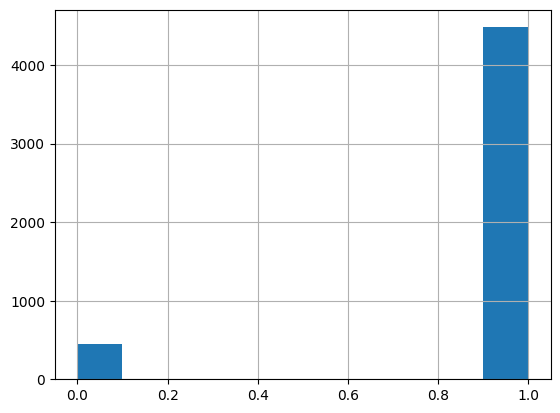

In [6]:
# Assuming your DataFrame is named 'df' and the target column is 'target'

# --- 1. Define the Target Ratio ---
# For example, a 10:1 ratio means there will be 10 majority samples for every 1 minority sample.
TARGET_RATIO = 10.0 # Majority:Minority (e.g., 10 for 10:1)

# --- 2. Get Current Class Counts ---
majority_count = len(df_trans[df_trans['RiskPerformance'] == 1])
minority_indices = df_trans[df_trans['RiskPerformance'] == 0].index
current_minority_count = len(minority_indices)

# --- 3. Calculate Required Minority Count ---
# Target Ratio = Majority Count / Required Minority Count
# Required Minority Count = Majority Count / Target Ratio
required_minority_count = int(majority_count / TARGET_RATIO)

# --- 4. Calculate How Many to Drop ---
num_to_drop = current_minority_count - required_minority_count

if num_to_drop <= 0:
    print(f"Cannot achieve a {TARGET_RATIO}:1 ratio by dropping. Need to drop {-num_to_drop} MORE majority samples.")
else:
    # --- 5. Randomly Select and Drop Indices ---
    np.random.seed(42) # Optional: for reproducibility
    indices_to_drop = np.random.choice(
        minority_indices,
        size=num_to_drop,
        replace=False
    )

    df_imbalanced = df_trans.drop(indices_to_drop)
    
    # --- Verification ---
    new_minority_count = len(df_imbalanced[df_imbalanced['RiskPerformance'] == 1])
    actual_ratio = majority_count / new_minority_count
    
    print("--- Imbalance Creation Summary ---")
    print(f"Target Ratio (0:1): {TARGET_RATIO}:1")
    print(f"Majority (0) Count: {majority_count}")
    print(f"Required Minority (1) Count: {required_minority_count}")
    print(f"Current Minority (1) Count: {current_minority_count}")
    print(f"Number of indices to drop: {num_to_drop}")
    print("--- Result ---")
    print(f"New Minority (1) Count: {new_minority_count}")
    print(f"Actual New Ratio (0:1): {actual_ratio:.2f}:1")

df_imbalanced['RiskPerformance'].hist()



X_train_imb = df_imbalanced.iloc[:,1:]
y_train_imb = df_imbalanced.iloc[:,0]




In [7]:
from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

RESULTS = {}
for method in ['tabsyn','tabdiff','tabddpm','tabscm','dcm','great','Smote','ADASYN','goggle','ctgan','causalTGAN']:
    RESULTS[method]= {'FNR':[],'FPR':[]}
    for i in range(1,6):
        if not method in ['Smote','ADASYN']:
            if method == 'dcm': 
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/heloc{i-1}.csv')
            elif method == 'tabscm': 
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/sample_test{i}.csv')
            elif method == 'goggle':
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/goggle{i}.csv')
            else:
                tabsyn_df = pd.read_csv(f'../syn_data_samples/heloc/{method}/sample{i}.csv')
                
                    

            tabsyn_df = tabsyn_df[tabsyn_df['RiskPerformance'] == 'Bad'].reset_index().drop(columns=['index'])


            New_data = {}
            for i,col in enumerate(tabsyn_df.columns):

                if i in INFO['num_col_idx']:
                    New_data[col] = Scaler[col].transform(tabsyn_df[col].values.reshape(-1,1)).flatten()
                
                elif i in INFO['cat_col_idx'] or INFO['target_col_idx']:
                    New_data[col] = Scaler[col].transform(tabsyn_df[col].values.flatten()).flatten()
                

            df_trans_tabsyn = pd.DataFrame(New_data)


            X_train_tabsyn = df_trans_tabsyn.iloc[:,1:]
            y_train_tabsyn = df_trans_tabsyn.iloc[:,0]

            N= (y_train_imb == 1).sum()-(y_train_imb==0).sum()
            # import numpy as np
            try:
                INDICES = np.random.choice(np.arange(1,X_train_tabsyn.shape[0]),N,replace=False)
            except:
                INDICES = np.arange(len(X_train_tabsyn))



            X_train_up = pd.concat([X_train_imb,X_train_tabsyn.iloc[INDICES,:]])
            y_train_up = pd.concat([y_train_imb,y_train_tabsyn.iloc[INDICES]])
        else:
            if method == 'ADASYN':
                ada_syn = ADASYN(random_state=i)

                X_train_up, y_train_up = ada_syn.fit_resample(X_train_imb, y_train_imb)

            elif method == 'Smote':
                smote = SMOTE(random_state=i)

                X_train_up, y_train_up = smote.fit_resample(X_train_imb, y_train_imb)




        forest = RandomForestClassifier(random_state=0,n_estimators=100,)#LogisticRegression()#GradientBoostingClassifier(random_state=0)#RandomForestClassifier(random_state=0,n_estimators=50,)KNeighborsClassifier(n_neighbors=5)
        forest.fit(X_train_up, y_train_up)
        
        y_pred = forest.predict(X_test)


        cm = confusion_matrix(y_pred,y_test)
    
        print('FPR',cm[2])
        RESULTS[method]['FPR'].append(cm[2])
        print('FNR',cm[3])
        RESULTS[method]['FNR'].append(cm[3])


FPR 0.222011385199241
FNR 0.32947976878612717
FPR 0.21062618595825428
FNR 0.325626204238921
FPR 0.21631878557874762
FNR 0.32755298651252407
FPR 0.22580645161290322
FNR 0.3217726396917148
FPR 0.2125237191650854
FNR 0.3236994219653179
FPR 0.20872865275142316
FNR 0.3198458574181118
FPR 0.2239089184060721
FNR 0.302504816955684
FPR 0.2428842504743833
FNR 0.31213872832369943
FPR 0.2333965844402277
FNR 0.29865125240847784
FPR 0.23719165085388993
FNR 0.302504816955684
FPR 0.2618595825426945
FNR 0.2813102119460501
FPR 0.2409867172675522
FNR 0.28516377649325625
FPR 0.25426944971537
FNR 0.28516377649325625
FPR 0.2903225806451613
FNR 0.21579961464354527
FPR 0.2504743833017078
FNR 0.29865125240847784
FPR 0.27893738140417457
FNR 0.28709055876685935
FPR 0.2732447817836812
FNR 0.27360308285163776
FPR 0.2675521821631879
FNR 0.30057803468208094
FPR 0.27893738140417457
FNR 0.2947976878612717
FPR 0.27514231499051234
FNR 0.279383429672447
FPR 0.051233396584440226
FNR 0.9325626204238922
FPR 0.05123339658444

In [8]:
fnr_data = {}
fpr_data = {}

for k,v in RESULTS.items():
    fnr_data[k] = np.array(v['FNR'])#-fnr
    fpr_data[k] = np.array(v['FPR'])#-fpr



fpr_df = pd.DataFrame(fpr_data)
fnr_df = pd.DataFrame(fnr_data)


#Columns = ['tabsyn','tabdiff','tabscm','tabddpm','great','goggle',,'ctgan','dcm','ADASYN','Smote']

fpr_df = fpr_df[Columns]
fnr_df = fnr_df[Columns]


fnr_df.insert(0,'Balanced',fnr)
fpr_df.insert(0,'Balanced',fpr)

In [9]:
Columns

['tabsyn',
 'tabdiff',
 'tabscm',
 'tabddpm',
 'great',
 'goggle',
 'ctgan',
 'causalTGAN',
 'dcm',
 'ADASYN',
 'Smote']

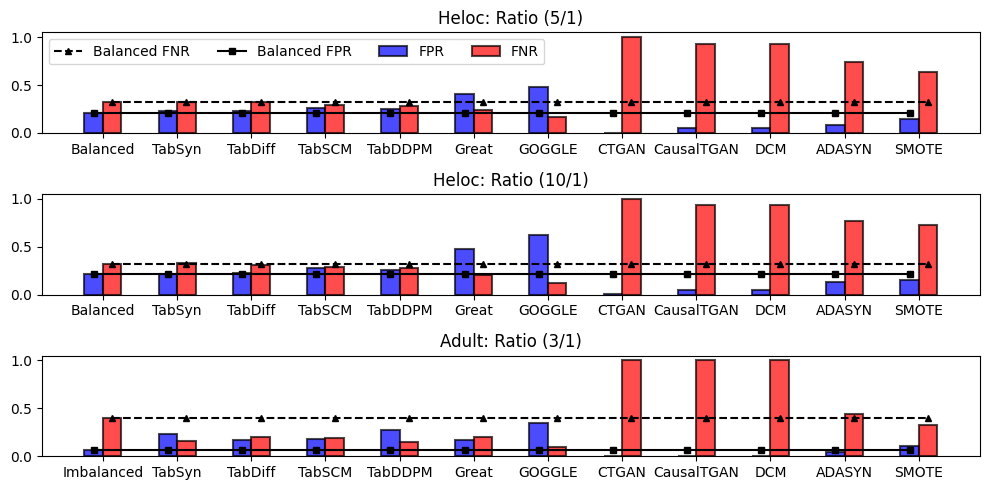

In [22]:
x = np.arange(fpr_df.shape[1])
width=0.25


fig, ax = plt.subplots(3,1,figsize=(10,5))
ax[0].bar(x-width/2,fpr_df_5.mean(),color='blue',edgecolor='black',lw=1.5,width=width,label="FPR",alpha=0.7)
ax[0].bar(x+width/2,fnr_df_5.mean(),color='red',edgecolor='black',lw=1.5,width=width, label='FNR',alpha=0.7)
ax[0].set_xticks(x,['Balanced','TabSyn','TabDiff','TabSCM','TabDDPM','Great','GOGGLE','CTGAN','CausalTGAN','DCM','ADASYN','SMOTE']);
ax[0].set_title('Heloc: Ratio (5/1)')
ax[0].plot(x+width/2,[fnr]*12,marker='^',color='black',markersize=5,ls='--',label='Balanced FNR')
ax[0].plot(x-width/2,[fpr]*12,marker='s',color='black',markersize=5,label='Balanced FPR')
# ax[0].legend()
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles, labels, ncol=len(labels))


ax[1].bar(x-width/2,fpr_df.mean(),color='blue',edgecolor='black',lw=1.5,width=width,label="FPR",alpha=0.7)
ax[1].bar(x+width/2,fnr_df.mean(),color='red',edgecolor='black',lw=1.5,width=width, label='FNR',alpha=0.7)
ax[1].set_xticks(x,['Balanced','TabSyn','TabDiff','TabSCM','TabDDPM','Great','GOGGLE','CTGAN','CausalTGAN','DCM','ADASYN','SMOTE']);
ax[1].set_title('Heloc: Ratio (10/1)')
ax[1].plot(x+width/2,[fnr]*12,marker='^',color='black',markersize=5,ls='--',label='Balanced FNR')
ax[1].plot(x-width/2,[fpr]*12,marker='s',color='black',markersize=5,label='Balanced FPR')
#plt.vlines(0.5,0.05,1.0,)

# handles, labels = ax[0].get_legend_handles_labels()
# ax[0].legend(handles, labels, ncol=len(labels))
#ax[1].legend(loc='upper left')



fpr_df_adult = pd.DataFrame([[0.07      , 0.2301092 , 0.17290692, 0.18538742, 0.27327093,
        0.17108684, 0.34919397, 0.        , 0.        , 0.        ,
        0.04888196, 0.10348414]], columns=['Imbalanced','TabSyn','TabDiff','TabSCM','TabDDPM','Great','GOGGLE','CTGAN','CausalTGAN','DCM','ADASYN','SMOTE'])


fnr_df_adult = pd.DataFrame([[0.4       , 0.15633293, 0.19839164, 0.18793727, 0.14418979,
        0.20201045, 0.09754725, 1.        , 1.        , 1.        ,
        0.44471251, 0.32714113]],columns=['Imbalanced','TabSyn','TabDiff','TabSCM','TabDDPM','Great','GOGGLE','CTGAN','CausalTGAN','DCM','ADASYN','SMOTE'])

fnr_adult = 0.4

fpr_adult = 0.07


ax[2].bar(x-width/2,fpr_df_adult.mean(),color='blue',edgecolor='black',lw=1.5,width=width,label="FPR",alpha=0.7)
ax[2].bar(x+width/2,fnr_df_adult.mean(),color='red',edgecolor='black',lw=1.5,width=width, label='FNR',alpha=0.7)
ax[2].set_xticks(x,['Imbalanced','TabSyn','TabDiff','TabSCM','TabDDPM','Great','GOGGLE','CTGAN','CausalTGAN','DCM','ADASYN','SMOTE']);
ax[2].set_title('Adult: Ratio (3/1)')
ax[2].plot(x+width/2,[fnr_adult]*12,marker='^',color='black',markersize=5,ls='--',label='Balanced FNR')
ax[2].plot(x-width/2,[fpr_adult]*12,marker='s',color='black',markersize=5,label='Balanced FPR')



fig.tight_layout()

In [23]:
fig.savefig('Upsampling_new.pdf',bbox_inches='tight')